## package & plot style

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from darts import TimeSeries
from darts.models import LinearRegressionModel
from darts.models import RandomForestModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, rmse, mae, r2_score
import shap


COLORS = {
    'IHSG': '#2E7D32',           # Green (primary)
    'IHSG_light': '#4CAF50',
    'IHSG_dark': '#1B5E20',    
    'STI': '#1976D2',            # Blue for regional index
    'Gold': '#FFD700',           # Gold color
    'Coal': '#FF5722',           # Orange-red
    'Copper': '#795548',         # Brown
    'Silver': '#9E9E9E',         # Gray
    'Tin': '#607D8B',            # Blue-gray
    'Nickel': '#FF9800',         # Orange
    'train': '#2E7D32',
    'actual': '#1976D2',
    'predicted': '#D32F2F',
    'error': '#9E9E9E',
    'split_line': '#616161',
}

COLOR_PALETTE = ['#2E7D32', '#D32F2F', '#F57C00', '#1976D2', '#7B1FA2', '#C2185B', '#FFD700']

# =========================================================================
# MATPLOTLIB THESIS STYLE
# =========================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100          # Display DPI
plt.rcParams['savefig.dpi'] = 300         # Export DPI (publication quality)
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1

# Font settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Georgia']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Line settings
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 0.8

# Grid settings
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linewidth'] = 0.5

# Legend settings
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.edgecolor'] = '0.8'

## Load and Merge Data

In [40]:
import pandas as pd
import numpy as np

# ============================================================================
# 1. LOADING DATASETS
# ============================================================================
print("="*60)
print("LOADING DATASETS")
print("="*60)

# IHSG (target) - Indonesian format dd/mm/yyyy
url_ihsg = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/ihsg_daily.csv'
ihsg = pd.read_csv(url_ihsg)
ihsg['Date'] = pd.to_datetime(ihsg['Date'], format='%d/%m/%Y')
ihsg.columns = ['Date', 'IHSG']
print(f"IHSG: {len(ihsg)} rows, {ihsg['Date'].min()} to {ihsg['Date'].max()}")

# STI - Indonesian format dd/mm/yyyy
url_sti = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/STI.csv'
sti = pd.read_csv(url_sti)
sti['Date'] = pd.to_datetime(sti['Date'], format='%d/%m/%Y')
sti.columns = ['Date', 'STI']
print(f"STI: {len(sti)} rows, {sti['Date'].min()} to {sti['Date'].max()}")

# Gold - Indonesian format dd/mm/yyyy
url_gold = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Gold.csv'
gold = pd.read_csv(url_gold)
gold['Date'] = pd.to_datetime(gold['Date'], format='%d/%m/%Y')
gold.columns = ['Date', 'Gold']
print(f"Gold: {len(gold)} rows, {gold['Date'].min()} to {gold['Date'].max()}")

# Commodities - US format mm/dd/yyyy
url_coal = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Coal.csv'
coal = pd.read_csv(url_coal)
coal['Date'] = pd.to_datetime(coal['Date'], format='%m/%d/%Y')
coal.columns = ['Date', 'Coal']
print(f"Coal: {len(coal)} rows, {coal['Date'].min()} to {coal['Date'].max()}")

url_copper = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Copper.csv'
copper = pd.read_csv(url_copper)
copper['Date'] = pd.to_datetime(copper['Date'], format='%m/%d/%Y')
copper.columns = ['Date', 'Copper']
print(f"Copper: {len(copper)} rows, {copper['Date'].min()} to {copper['Date'].max()}")

url_silver = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Silver.csv'
silver = pd.read_csv(url_silver)
silver['Date'] = pd.to_datetime(silver['Date'], format='%m/%d/%Y')
silver.columns = ['Date', 'Silver']
print(f"Silver: {len(silver)} rows, {silver['Date'].min()} to {silver['Date'].max()}")

url_tin = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Tin.csv'
tin = pd.read_csv(url_tin)
tin['Date'] = pd.to_datetime(tin['Date'], format='%m/%d/%Y')
tin.columns = ['Date', 'Tin']
print(f"Tin: {len(tin)} rows, {tin['Date'].min()} to {tin['Date'].max()}")

url_nickel = 'https://raw.githubusercontent.com/ravsssh/tesis-hakam/refs/heads/main/dataset/Nickel.csv'
nickel = pd.read_csv(url_nickel)
nickel['Date'] = pd.to_datetime(nickel['Date'], format='%m/%d/%Y')
nickel.columns = ['Date', 'Nickel']
print(f"Nickel: {len(nickel)} rows, {nickel['Date'].min()} to {nickel['Date'].max()}")

# ============================================================================
# 2. CLEANING FUNCTION
# ============================================================================
def clean_dataset(df, name):
    """
    Clean dataset: set index, drop NaT, remove duplicates, sort
    """
    # Set Date as index
    df = df.set_index('Date')
    
    # Drop rows with NaT index
    before = len(df)
    df = df[df.index.notna()]
    after = len(df)
    if before != after:
        print(f"  {name}: Dropped {before - after} NaT rows")
    
    # Check for duplicates
    if df.index.duplicated().any():
        n_dupes = df.index.duplicated().sum()
        print(f"  {name}: Found {n_dupes} duplicate dates - keeping first occurrence")
        df = df[~df.index.duplicated(keep='first')]
    
    # Sort by date
    df = df.sort_index()
    
    return df

# ============================================================================
# 3. APPLY CLEANING TO ALL DATASETS
# ============================================================================
print("\n" + "="*60)
print("CLEANING DATASETS")
print("="*60)

ihsg = clean_dataset(ihsg, "IHSG")
sti = clean_dataset(sti, "STI")
gold = clean_dataset(gold, "Gold")
coal = clean_dataset(coal, "Coal")
copper = clean_dataset(copper, "Copper")
silver = clean_dataset(silver, "Silver")
tin = clean_dataset(tin, "Tin")
nickel = clean_dataset(nickel, "Nickel")

# ============================================================================
# 4. VALIDATE CLEANING
# ============================================================================
print("\n" + "="*60)
print("VALIDATION AFTER CLEANING")
print("="*60)

datasets = {
    "IHSG": ihsg, "STI": sti, "Gold": gold, "Coal": coal,
    "Copper": copper, "Silver": silver, "Tin": tin, "Nickel": nickel
}

for name, df in datasets.items():
    print(f"{name}:")
    print(f"  Rows: {len(df)}")
    print(f"  Sorted: {df.index.is_monotonic_increasing}")
    print(f"  Unique dates: {df.index.is_unique}")
    print(f"  NaT in index: {df.index.isna().sum()}")
    print(f"  NaN in values: {df.isnull().sum().values[0]}")

# ============================================================================
# 5. MERGE ALL DATASETS
# ============================================================================
print("\n" + "="*60)
print("MERGING DATASETS")
print("="*60)

# Concat dengan sort=False (semua sudah sorted sebelumnya)
all_data = pd.concat(
    [ihsg, sti, gold, coal, copper, silver, tin, nickel], 
    axis=1, 
    sort=False
)

# Filter to IHSG date range
start_date = ihsg.index.min()
end_date = ihsg.index.max()
all_data = all_data[start_date:end_date]

print(f"Range: {all_data.index.min()} to {all_data.index.max()}")
print(f"Total rows: {len(all_data)}")
print(f"\nMissing values:")
print(all_data.isnull().sum())
print(f"\nMissing values (%):")
print((all_data.isnull().sum() / len(all_data) * 100).round(2))

# ============================================================================
# 6. FORWARD FILL MISSING VALUES
# ============================================================================
print("\n" + "="*60)
print("HANDLING MISSING VALUES (FORWARD FILL)")
print("="*60)

# Gunakan ffill() langsung (pandas 2.0+)
all_data_filled = all_data.ffill()

print(f"Missing values after forward fill:")
print(all_data_filled.isnull().sum())

# Check if any remaining NaNs at start
if all_data_filled.isnull().any().any():
    print("\nWarning: Some NaNs remain at start of series. Dropping those rows...")
    all_data_filled = all_data_filled.dropna()
    print(f"Final rows after dropna: {len(all_data_filled)}")

print("\n" + "="*60)
print("DATA PREPARATION COMPLETE")
print("="*60)
print(all_data_filled.head())
print(f"\nFinal shape: {all_data_filled.shape}")
print(f"Date range: {all_data_filled.index.min()} to {all_data_filled.index.max()}")

LOADING DATASETS
IHSG: 2660 rows, 2015-01-02 00:00:00 to 2025-12-30 00:00:00
STI: 2766 rows, 2015-01-02 00:00:00 to 2025-12-31 00:00:00
Gold: 2857 rows, 2015-01-01 00:00:00 to 2025-12-31 00:00:00
Coal: 2839 rows, 2015-01-02 00:00:00 to 2025-12-31 00:00:00
Copper: 2780 rows, 2015-01-02 00:00:00 to 2025-12-31 00:00:00
Silver: 2857 rows, 2015-01-01 00:00:00 to 2025-12-31 00:00:00
Tin: 2780 rows, 2015-01-02 00:00:00 to 2025-12-31 00:00:00
Nickel: 2774 rows, 2015-01-02 00:00:00 to 2025-12-31 00:00:00

CLEANING DATASETS
  Gold: Dropped 4 NaT rows

VALIDATION AFTER CLEANING
IHSG:
  Rows: 2660
  Sorted: True
  Unique dates: True
  NaT in index: 0
  NaN in values: 0
STI:
  Rows: 2766
  Sorted: True
  Unique dates: True
  NaT in index: 0
  NaN in values: 0
Gold:
  Rows: 2853
  Sorted: True
  Unique dates: True
  NaT in index: 0
  NaN in values: 0
Coal:
  Rows: 2839
  Sorted: True
  Unique dates: True
  NaT in index: 0
  NaN in values: 0
Copper:
  Rows: 2780
  Sorted: True
  Unique dates: True
  

In [41]:
all_data

,IHSG,STI,Gold,Coal,Copper,Silver,Tin,Nickel
Date,,,,,,,,
2015-01-02,5242.769,3370.59,1188.39,61.30,6255.0,15.7465,19645.0,14830.0
2015-01-05,5219.995,3328.28,1204.86,61.25,6145.0,16.1885,19495.0,15200.0
2015-01-06,5169.060,3281.95,1218.58,61.45,6145.0,16.5365,19775.0,15260.0
2015-01-07,5207.118,3298.36,1211.41,60.60,6115.0,16.5354,19700.0,15550.0
2015-01-08,5211.828,3345.11,1208.79,60.60,6104.0,16.3651,19780.0,15550.0
...,...,...,...,...,...,...,...,...
2025-12-22,8645.844,4610.29,4443.60,108.25,11925.0,69.0383,42947.0,15276.0
2025-12-23,8584.782,4638.97,4484.47,108.25,12060.5,71.4300,42792.0,15739.0
2025-12-24,8537.911,4636.34,4479.42,108.25,12162.5,71.8700,42815.0,15786.0


In [43]:
from darts import TimeSeries
from darts.utils.missing_values import fill_missing_values
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import MinMaxScaler

# === 1. Buat TimeSeries dengan freq Business Day ===
ihsg_ts = TimeSeries.from_dataframe(
    all_data[["IHSG"]],
    fill_missing_dates=True,
    freq="B",
    fillna_value=None
)

covar_ts = TimeSeries.from_dataframe(
    all_data[["STI", "Gold", "Coal", "Copper", "Silver", "Tin", "Nickel"]],
    fill_missing_dates=True,
    freq="B",
    fillna_value=None
)

# Cek missing sebelum fill
print("Before fill_missing_values:")
print(f"IHSG NaN: {ihsg_ts.to_dataframe().isnull().sum().values[0]}")
print(f"Covar NaN:\n{covar_ts.to_dataframe().isnull().sum()}")

# === 2. Fill missing values (interpolasi) ===
ihsg_ts = fill_missing_values(ihsg_ts)
covar_ts = fill_missing_values(covar_ts)

# Validasi
print(f"\nAfter fill_missing_values:")
print(f"IHSG NaN: {ihsg_ts.to_dataframe().isnull().sum().values[0]}")
print(f"Covar NaN:\n{covar_ts.to_dataframe().isnull().sum()}")
print(f"\nIHSG: {len(ihsg_ts)} timesteps, {ihsg_ts.start_time()} to {ihsg_ts.end_time()}")
print(f"Covar: {len(covar_ts)} timesteps, {covar_ts.start_time()} to {covar_ts.end_time()}")

# === 1. Prepare target classification Model 2 ===
ihsg_full_df = ihsg_ts.to_dataframe()
ihsg_returns2_df = ihsg_full_df.pct_change().dropna()
ihsg_returns2_df.columns = ["IHSG_Return"]
ihsg_direction2_df = ihsg_returns2_df.copy()
ihsg_direction2_df["IHSG_Direction"] = (ihsg_direction2_df["IHSG_Return"] > 0).astype(float)
ihsg_direction2_df = ihsg_direction2_df[["IHSG_Direction"]]

print("Class distribution (Model 2 - Daily):")
print(f"  Naik  (1): {int(ihsg_direction2_df['IHSG_Direction'].sum())} hari ({ihsg_direction2_df['IHSG_Direction'].mean()*100:.1f}%)")
print(f"  Turun (0): {int((1-ihsg_direction2_df['IHSG_Direction']).sum())} hari ({(1-ihsg_direction2_df['IHSG_Direction'].mean())*100:.1f}%)")

# === 2. TimeSeries ===
target_cls2 = TimeSeries.from_dataframe(ihsg_direction2_df)

# Train/Test split (sama ratio dengan sebelumnya)
split_point2 = int(len(target_cls2) * 0.8)
target_cls2_train = target_cls2[:split_point2]
target_cls2_test = target_cls2[split_point2:]
target_cls2_full = target_cls2_train.append(target_cls2_test)

# Covariates: trim 1 baris pertama agar align dengan returns, lalu scale
covar_trimmed = covar_ts[1:]  # trim karena pct_change hilang 1 baris
covar_trim_train = covar_trimmed[:split_point2]
covar_trim_test = covar_trimmed[split_point2:]

scaler_COVAR2_cls = Scaler(MinMaxScaler(feature_range=(-1, 1)))
covar_cls2_train_scaled = scaler_COVAR2_cls.fit_transform(covar_trim_train)
covar_cls2_test_scaled = scaler_COVAR2_cls.transform(covar_trim_test)
covar_cls2_full_scaled = covar_cls2_train_scaled.append(covar_cls2_test_scaled)

print(f"\nTrain: {len(target_cls2_train)} days ({target_cls2_train.start_time()} to {target_cls2_train.end_time()})")
print(f"Test: {len(target_cls2_test)} days ({target_cls2_test.start_time()} to {target_cls2_test.end_time()})")
print(f"Train dist: Naik={int(target_cls2_train.values().sum())}, Turun={len(target_cls2_train)-int(target_cls2_train.values().sum())}")
print(f"Test dist: Naik={int(target_cls2_test.values().sum())}, Turun={len(target_cls2_test)-int(target_cls2_test.values().sum())}")
print(f"\nTarget aligned with covariates: {len(target_cls2) == len(covar_trimmed)}")

Before fill_missing_values:
IHSG NaN: 208
Covar NaN:
STI       248
Gold      210
Coal      210
Copper    261
Silver    210
Tin       261
Nickel    267
dtype: int64

After fill_missing_values:
IHSG NaN: 0
Covar NaN:
STI       0
Gold      0
Coal      0
Copper    0
Silver    0
Tin       0
Nickel    0
dtype: int64

IHSG: 2868 timesteps, 2015-01-02 00:00:00 to 2025-12-30 00:00:00
Covar: 2868 timesteps, 2015-01-02 00:00:00 to 2025-12-30 00:00:00
Class distribution (Model 2 - Daily):
  Naik  (1): 1540 hari (53.7%)
  Turun (0): 1327 hari (46.3%)

Train: 2293 days (2015-01-05 00:00:00 to 2023-10-18 00:00:00)
Test: 574 days (2023-10-19 00:00:00 to 2025-12-30 00:00:00)
Train dist: Naik=1234, Turun=1059
Test dist: Naik=306, Turun=268

Target aligned with covariates: True


In [45]:
from darts.models import SKLearnClassifierModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


# === 3. Baseline RF Classifier Model 2 ===
rf_clf_model2 = SKLearnClassifierModel(
    model=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    lags=1,
    lags_past_covariates=1,
    output_chunk_length=1
)

rf_clf_model2.fit(
    series=target_cls2_train,
    past_covariates=covar_cls2_full_scaled
)

hf_cls2 = rf_clf_model2.historical_forecasts(
    series=target_cls2_full,
    past_covariates=covar_cls2_full_scaled,
    start=len(target_cls2_train),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
    show_warnings=False
)

y_true2 = target_cls2_test.values().flatten()
y_pred2 = hf_cls2.values().flatten()

print("=== RF Classifier Baseline (Model 2 - Daily) ===")
print(f"Accuracy:  {accuracy_score(y_true2, y_pred2):.4f}")
print(f"F1 Macro:  {f1_score(y_true2, y_pred2, average='macro'):.4f}")
print(f"\n{classification_report(y_true2, y_pred2, target_names=['Turun', 'Naik'])}")

# === 4. Optuna RF Classifier Model 2 ===
def objective_cls2_rf(trial):
    lags = trial.suggest_categorical("lags", [1, 3, 5, 10, 20])
    lags_past_covariates = trial.suggest_categorical("lags_past_covariates", [1, 3, 5, 10, 20])
    
    n_estimators = trial.suggest_categorical("n_estimators", [50, 100, 200])
    max_depth = trial.suggest_categorical("max_depth", [3, 5, 7, None])
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    min_samples_split = trial.suggest_categorical("min_samples_split", [2, 5, 10])
    min_samples_leaf = trial.suggest_categorical("min_samples_leaf", [1, 2, 4])
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = SKLearnClassifierModel(
        model=RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            max_features=max_features,
            bootstrap=bootstrap,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            criterion=criterion,
            random_state=42,
            n_jobs=-1
        ),
        lags=lags,
        lags_past_covariates=lags_past_covariates,
        output_chunk_length=1
    )

    model.fit(
        series=target_cls2_train,
        past_covariates=covar_cls2_full_scaled
    )

    hf = model.historical_forecasts(
        series=target_cls2_full,
        past_covariates=covar_cls2_full_scaled,
        start=len(target_cls2_train),
        forecast_horizon=1,
        stride=1,
        retrain=False,
        last_points_only=True,
        show_warnings=False
    )

    y_true = target_cls2_test.values().flatten()
    y_pred = hf.values().flatten()
    
    return f1_score(y_true, y_pred, average='macro')

study_cls2_rf = optuna.create_study(direction="maximize")
study_cls2_rf.optimize(objective_cls2_rf, n_trials=200, callbacks=[print_callback])

print("=" * 60)
print(f"Best F1 (macro): {study_cls2_rf.best_value:.4f}")
print(f"Best params: {study_cls2_rf.best_trial.params}")

This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 06:10:10,694] A new study created in memory with name: no-name-eaf8503b-0db4-4c76-a26b-8077b62d6ee6
This model will treat target `series` lagged values as numeric input features (and not categorical).


=== RF Classifier Baseline (Model 2 - Daily) ===
Accuracy:  0.5052
F1 Macro:  0.4891

              precision    recall  f1-score   support

       Turun       0.48      0.73      0.58       268
        Naik       0.57      0.31      0.40       306

    accuracy                           0.51       574
   macro avg       0.52      0.52      0.49       574
weighted avg       0.53      0.51      0.48       574



[I 2026-02-11 06:10:11,454] Trial 0 finished with value: 0.35273311375399546 and parameters: {'lags': 20, 'lags_past_covariates': 10, 'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': False, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 0 with value: 0.35273311375399546.
This model will treat target `series` lagged values as numeric input features (and not categorical).


Trial 0: MAPE=0.3527, params={'lags': 20, 'lags_past_covariates': 10, 'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': False, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'gini'}
  Best so far: MAPE=0.3527, params={'lags': 20, 'lags_past_covariates': 10, 'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': False, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'gini'}



[I 2026-02-11 06:10:12,040] Trial 1 finished with value: 0.34698521046643915 and parameters: {'lags': 20, 'lags_past_covariates': 10, 'n_estimators': 50, 'max_depth': 7, 'max_features': 'sqrt', 'bootstrap': False, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'entropy'}. Best is trial 0 with value: 0.35273311375399546.
This model will treat target `series` lagged values as numeric input features (and not categorical).


...

Trial 197: MAPE=0.3544, params={'lags': 3, 'lags_past_covariates': 10, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}
  Best so far: MAPE=0.5349, params={'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}



[I 2026-02-11 06:12:27,233] Trial 198 finished with value: 0.5348596534049305 and parameters: {'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 117 with value: 0.5348596534049305.
This model will treat target `series` lagged values as numeric input features (and not categorical).


Trial 198: MAPE=0.5349, params={'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}
  Best so far: MAPE=0.5349, params={'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}



[I 2026-02-11 06:12:27,868] Trial 199 finished with value: 0.5348596534049305 and parameters: {'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 117 with value: 0.5348596534049305.


Trial 199: MAPE=0.5349, params={'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}
  Best so far: MAPE=0.5349, params={'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}

Best F1 (macro): 0.5349
Best params: {'lags': 3, 'lags_past_covariates': 1, 'n_estimators': 50, 'max_depth': None, 'max_features': 'sqrt', 'bootstrap': True, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}


In [47]:
from sklearn.linear_model import LogisticRegression


# === Optuna Logistic Regression Model 2 ===
def objective_lr_cls2(trial):
    lags = trial.suggest_categorical("lags", [1, 3, 5, 10, 20])
    lags_past_covariates = trial.suggest_categorical("lags_past_covariates", [1, 3, 5, 10, 20])
    C = trial.suggest_float("C", 0.001, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])

    model = SKLearnClassifierModel(
        model=LogisticRegression(
            C=C,
            penalty=penalty,
            solver="liblinear",
            random_state=42,
            max_iter=5000
        ),
        lags=lags,
        lags_past_covariates=lags_past_covariates,
        output_chunk_length=1
    )

    model.fit(
        series=target_cls2_train,
        past_covariates=covar_cls2_full_scaled
    )

    hf = model.historical_forecasts(
        series=target_cls2_full,
        past_covariates=covar_cls2_full_scaled,
        start=len(target_cls2_train),
        forecast_horizon=1,
        stride=1,
        retrain=False,
        last_points_only=True,
        show_warnings=False
    )

    y_true = target_cls2_test.values().flatten()
    y_pred = hf.values().flatten()
    
    return f1_score(y_true, y_pred, average='macro')

study_lr_cls2 = optuna.create_study(direction="maximize")
study_lr_cls2.optimize(objective_lr_cls2, n_trials=100, callbacks=[print_callback])

print("=" * 60)
print(f"Best F1 (macro): {study_lr_cls2.best_value:.4f}")
print(f"Best params: {study_lr_cls2.best_trial.params}")

[I 2026-02-11 06:15:07,523] A new study created in memory with name: no-name-a7602f83-2385-4ec9-9609-ad44e8f93498
This model will treat target `series` lagged values as numeric input features (and not categorical).
[I 2026-02-11 06:15:07,907] Trial 0 finished with value: 0.4514203069185681 and parameters: {'lags': 5, 'lags_past_covariates': 1, 'C': 0.019568108895524412, 'penalty': 'l2'}. Best is trial 0 with value: 0.4514203069185681.
This model will treat target `series` lagged values as numeric input features (and not categorical).


Trial 0: MAPE=0.4514, params={'lags': 5, 'lags_past_covariates': 1, 'C': 0.019568108895524412, 'penalty': 'l2'}
  Best so far: MAPE=0.4514, params={'lags': 5, 'lags_past_covariates': 1, 'C': 0.019568108895524412, 'penalty': 'l2'}



[I 2026-02-11 06:15:08,397] Trial 1 finished with value: 0.41949838187702265 and parameters: {'lags': 3, 'lags_past_covariates': 20, 'C': 5.599629140491941, 'penalty': 'l2'}. Best is trial 0 with value: 0.4514203069185681.
This model will treat target `series` lagged values as numeric input features (and not categorical).


Trial 1: MAPE=0.4195, params={'lags': 3, 'lags_past_covariates': 20, 'C': 5.599629140491941, 'penalty': 'l2'}
  Best so far: MAPE=0.4514, params={'lags': 5, 'lags_past_covariates': 1, 'C': 0.019568108895524412, 'penalty': 'l2'}



[I 2026-02-11 06:15:08,748] Trial 2 finished with value: 0.4074441011756431 and parameters: {'lags': 10, 'lags_past_covariates': 3, 'C': 1.6813766998307422, 'penalty': 'l2'}. Best is trial 0 with value: 0.4514203069185681.
This model will treat target `series` lagged values as numeric input features (and not categorical).


...

Trial 97: MAPE=0.3477, params={'lags': 5, 'lags_past_covariates': 20, 'C': 0.06353278121227351, 'penalty': 'l1'}
  Best so far: MAPE=0.5512, params={'lags': 5, 'lags_past_covariates': 20, 'C': 0.09387822047515841, 'penalty': 'l1'}



[I 2026-02-11 06:16:05,214] Trial 98 finished with value: 0.5358599973558882 and parameters: {'lags': 5, 'lags_past_covariates': 10, 'C': 0.1522601978684139, 'penalty': 'l1'}. Best is trial 82 with value: 0.551183698590992.
This model will treat target `series` lagged values as numeric input features (and not categorical).


Trial 98: MAPE=0.5359, params={'lags': 5, 'lags_past_covariates': 10, 'C': 0.1522601978684139, 'penalty': 'l1'}
  Best so far: MAPE=0.5512, params={'lags': 5, 'lags_past_covariates': 20, 'C': 0.09387822047515841, 'penalty': 'l1'}



[I 2026-02-11 06:16:05,568] Trial 99 finished with value: 0.3477272727272727 and parameters: {'lags': 5, 'lags_past_covariates': 20, 'C': 0.04462539467170404, 'penalty': 'l1'}. Best is trial 82 with value: 0.551183698590992.


Trial 99: MAPE=0.3477, params={'lags': 5, 'lags_past_covariates': 20, 'C': 0.04462539467170404, 'penalty': 'l1'}
  Best so far: MAPE=0.5512, params={'lags': 5, 'lags_past_covariates': 20, 'C': 0.09387822047515841, 'penalty': 'l1'}

Best F1 (macro): 0.5512
Best params: {'lags': 5, 'lags_past_covariates': 20, 'C': 0.09387822047515841, 'penalty': 'l1'}


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
The model is probabilistic, but num_samples=1 will be used for explainability.
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
Using 2291 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


=== Random Forest Classifier Best (Model 2 - Daily) ===
Accuracy:  0.5662
F1 Macro:  0.5349

              precision    recall  f1-score   support

       Turun       0.56      0.33      0.41       268
        Naik       0.57      0.77      0.66       306

    accuracy                           0.57       574
   macro avg       0.56      0.55      0.53       574
weighted avg       0.56      0.57      0.54       574

=== Logistic Regression Classifier Best (Model 2 - Daily) ===
Accuracy:  0.5662
F1 Macro:  0.5512

              precision    recall  f1-score   support

       Turun       0.55      0.41      0.47       268
        Naik       0.58      0.70      0.63       306

    accuracy                           0.57       574
   macro avg       0.56      0.56      0.55       574
weighted avg       0.56      0.57      0.56       574

=== SHAP RF Model 2 ===


  0%|          | 0/2291 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: U

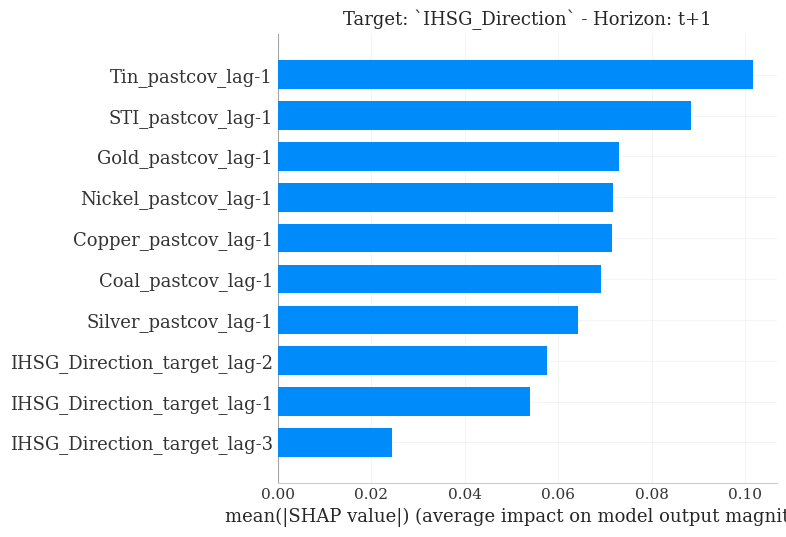

  0%|          | 0/2291 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: U

In [ ]:
from darts.explainability.shap_explainer import ShapExplainer

# === Best RF Classifier Model 2 ===
best_rf_cls2 = SKLearnClassifierModel(
    model=RandomForestClassifier(
        n_estimators=50,
        max_depth=None,
        max_features="sqrt",
        bootstrap=True,
        min_samples_split=2,
        min_samples_leaf=4,
        criterion="gini",
        random_state=42,
        n_jobs=-1
    ),
    lags=3,
    lags_past_covariates=1,
    output_chunk_length=1
)

best_rf_cls2.fit(
    series=target_cls2_train,
    past_covariates=covar_cls2_full_scaled
)

hf_rf_cls2 = best_rf_cls2.historical_forecasts(
    series=target_cls2_full,
    past_covariates=covar_cls2_full_scaled,
    start=len(target_cls2_train),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
    show_warnings=False
)

# === Best LR Classifier Model 2 ===
best_lr_cls2 = SKLearnClassifierModel(
    model=LogisticRegression(
        C=0.0939,
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=5000
    ),
    lags=5,
    lags_past_covariates=20,
    output_chunk_length=1
)

best_lr_cls2.fit(
    series=target_cls2_train,
    past_covariates=covar_cls2_full_scaled
)

hf_lr_cls2 = best_lr_cls2.historical_forecasts(
    series=target_cls2_full,
    past_covariates=covar_cls2_full_scaled,
    start=len(target_cls2_train),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
    show_warnings=False
)

# === Evaluate Both ===
y_true2 = target_cls2_test.values().flatten()
y_pred_rf2 = hf_rf_cls2.values().flatten()
y_pred_lr2 = hf_lr_cls2.values().flatten()

print("=== Random Forest Classifier Best (Model 2 - Daily) ===")
print(f"Accuracy:  {accuracy_score(y_true2, y_pred_rf2):.4f}")
print(f"F1 Macro:  {f1_score(y_true2, y_pred_rf2, average='macro'):.4f}")
print(f"\n{classification_report(y_true2, y_pred_rf2, target_names=['Turun', 'Naik'])}")

print("=== Logistic Regression Classifier Best (Model 2 - Daily) ===")
print(f"Accuracy:  {accuracy_score(y_true2, y_pred_lr2):.4f}")
print(f"F1 Macro:  {f1_score(y_true2, y_pred_lr2, average='macro'):.4f}")
print(f"\n{classification_report(y_true2, y_pred_lr2, target_names=['Turun', 'Naik'])}")

# === SHAP RF ===
shap_rf_cls2 = ShapExplainer(
    model=best_rf_cls2,
    background_series=target_cls2_train,
    background_past_covariates=covar_cls2_full_scaled
)

print("=== SHAP RF Model 2 ===")
shap_rf_cls2.summary_plot(horizons=[1], plot_type="bar")
shap_rf_cls2.summary_plot(horizons=[1], plot_type="dot")

# === SHAP LR ===
shap_lr_cls2 = ShapExplainer(
    model=best_lr_cls2,
    background_series=target_cls2_train,
    background_past_covariates=covar_cls2_full_scaled
)

print("=== SHAP LR Model 2 ===")
shap_lr_cls2.summary_plot(horizons=[1], plot_type="bar")
shap_lr_cls2.summary_plot(horizons=[1], plot_type="dot")

# === Optuna Visualizations ===
fig1 = plot_optimization_history(study_cls2_rf)
fig1.show()
fig2 = plot_param_importances(study_cls2_rf)
fig2.show()

fig3 = plot_optimization_history(study_lr_cls2)
fig3.show()
fig4 = plot_param_importances(study_lr_cls2)
fig4.show()